# Phase II — Exploratory Data Analysis

**Project GitHub repository:** https://github.com/VincentPit/ds_in_da_wild

**Collaborators:** Junyi Li (jl4724), Jinyue Wang (jw2796), Wenzhuo Zhang (wz475), Qiaohao Hu (qh252)

**Submitted:** March 18, 2026

## 1) Research Questions

**Primary question:**
How does daily roadway traffic volume relate to motor vehicle collision frequency and injury severity in NYC?

**Sub-questions:**
1. On high-traffic days, are there systematically more crashes, injuries, and fatalities — even after controlling for day-of-week and seasonal patterns in traffic volume?
2. Does the mix of crash victims (pedestrians vs. cyclists vs. motorists) shift on higher-traffic days, suggesting that volume disproportionately endangers vulnerable road users?
3. Does ambient street-level temperature modify the traffic–crash relationship — i.e., do high-volume days become even more dangerous at temperature extremes?
4. Do the volume–crash and volume–injury relationships vary across boroughs, indicating that some areas bear a disproportionate share of crash risk per unit of traffic?
5. What day-of-week and seasonal cycles characterize both traffic volume and crash outcomes, and must be controlled for when isolating the volume effect?


## 2) Data Description

We use three of the four Phase I datasets as primary inputs. The Climate Projections dataset (decadal projections, no daily granularity) is not used here.

---

### Dataset 1: Traffic Volume Counts (Historical)
**Source:** NYC Open Data — ID `btm5-ppia`
**Raw data:** `data/Traffic_Volume_Counts_(Historical)_20260225.csv`

- **Why we use it:** Most direct measure of roadway exposure in NYC — a prerequisite for understanding whether more vehicles on the road leads to more crashes.
- **Rows:** 42,756. Each row is one road-segment/direction combination on one date.
- **Columns (31):** `SegmentID`, `Roadway Name`, `From`, `To`, `Direction`, `Date`, plus 24 hourly vehicle-count columns (`12:00-1:00 AM` … `11:00-12:00 AM`).
- **Columns used:** `Date`, `SegmentID`, and all 24 hourly counts (summed to `daily_volume`). Covers 1,956 unique segments across 1,276 named roadways, Jan 2012 – May 2021.
- **Why it was created:** NYC DOT collects automatic traffic recorder (ATR) counts to inform infrastructure planning and policy.
- **Funding:** NYC Department of Transportation.
- **Potential biases:** Sensors are not uniformly distributed — some boroughs and road types are overrepresented. Counts reflect vehicle passage at a fixed point, not true network-wide volume. Missing sensor readings are simply absent from the data.
- **Preprocessing:** `Date` parsed to datetime; 24 hourly columns detected by regex and summed to `daily_volume`; rows aggregated to city-wide daily total (`total_daily_volume`) and segment count (`traffic_segment_rows`); `vol_per_segment` = `total_daily_volume / traffic_segment_rows` computed to normalise for uneven sensor coverage.
- **People involved:** No personal data collected; drivers are not aware their vehicles are being counted.

---

### Dataset 2: Motor Vehicle Collisions – Crashes
**Source:** NYC Open Data — ID `h9gi-nx95`
**Raw data:** `data/Motor_Vehicle_Collisions_-_Crashes_20260225.csv`

- **Why we use it:** Provides the outcome variable — crash frequency and severity — that we want to explain using traffic volume and temperature.
- **Rows:** 2,244,212. Each row is one reported collision.
- **Columns (29):** `COLLISION_ID`, `CRASH DATE`, `CRASH TIME`, `BOROUGH`, `ZIP CODE`, `LATITUDE`, `LONGITUDE`, injury/fatality counts split by pedestrian/cyclist/motorist, up to 5 contributing factors, and up to 5 vehicle types.
- **Columns used:** `COLLISION_ID` (for crash counts), `CRASH DATE`, `BOROUGH`, `LATITUDE`, `LONGITUDE`, `NUMBER OF PERSONS INJURED/KILLED`, `NUMBER OF PEDESTRIANS/CYCLISTS/MOTORISTS INJURED`. Covers Jul 2012 – Feb 2026.
- **Why it was created:** NYPD is required to file a report for every collision involving injury, death, or property damage over $1,000.
- **Funding:** NYPD / NYC Open Data initiative.
- **Potential biases:** Under-reporting likely for minor property-damage-only crashes. Geocoding failures produce missing lat/lon. Borough assignment missing in ~10% of rows. Reporting practices may have changed over time.
- **Preprocessing:** `CRASH DATE` parsed to datetime; all injury/fatality count columns coerced to numeric with `NaN → 0`; aggregated to daily crash count, total injuries, and total fatalities; `injuries_per_crash` and `fatalities_per_crash` computed.
- **People involved:** Crash records involve real individuals. Data is anonymised (no names); released as open government data.

---

### Dataset 3: Hyperlocal Temperature Monitoring
**Source:** NYC Open Data
**Raw data:** `data/Hyperlocal_Temperature_Monitoring_20260225.csv`

- **Why we use it:** Supplementary temperature series to explore whether extreme heat or cold modifies the traffic–crash relationship during the sensor deployment window.
- **Rows:** 2,097,150. Each row is one hourly air-temperature reading from one sensor on one date.
- **Columns (10):** `Sensor.ID`, `AirTemp` (°F), `Day`, `Hour`, `Latitude`, `Longitude`, `Year`, `Install.Type`, `Borough`, `ntacode`.
- **Columns used:** `Day`, `AirTemp`. Covers 423 sensors across Brooklyn, Bronx, Manhattan, and Queens, Jun 2018 – Oct 2019 only.
- **Why it was created:** NYC studied street-level urban heat island effects using low-cost sensors on street trees and light poles — distinct from airport-based weather stations.
- **Funding:** NYC Parks & Recreation / urban heat island research program.
- **Potential biases:** Staten Island has no sensor coverage. Sensors near trees may read differently from open-road sensors. The 15-month window (summer-heavy) is not a representative annual sample.
- **Preprocessing:** `Day` parsed to datetime; `AirTemp` averaged across all active sensors per day to produce `hyperlocal_temp_daily_avg`.
- **People involved:** No personal data. Sensors are passive environmental monitors.


## 3) Data Collection & Cleaning

All raw CSV files were downloaded from NYC Open Data on February 25, 2026 and stored in the `data/` folder. The full ingestion and merge pipeline runs in the setup cell below — **no pre-built CSV is used**.

**Pipeline summary:**
1. **Traffic Volume** — `Date` parsed to datetime; the 24 hourly count columns are detected by regex and summed to `daily_volume` per row; rows aggregated to city-wide daily totals (`total_daily_volume`) and segment count (`traffic_segment_rows`).
2. **Motor Vehicle Collisions** — `CRASH DATE` parsed to datetime; all eight injury/fatality count columns coerced to numeric with `NaN → 0`; aggregated to daily crash count, total injuries, and total fatalities.
3. **Hyperlocal Temperature** — `Day` parsed to datetime; `AirTemp` averaged across all active sensors per day → `hyperlocal_temp_daily_avg`.
4. **Merge** — Traffic and crash daily frames joined via **inner join** on `Date` (effective window: Sep 2012 – May 2021). Hyperlocal temperature left-joined, yielding `NaN` outside the sensor window (Jun 2018 – Oct 2019).
5. **Derived features** — `injuries_per_crash`, `fatalities_per_crash`, and `vol_per_segment` (`total_daily_volume / traffic_segment_rows`) computed on the merged frame.
6. **Calendar features** — `day_of_week`, `month`, `year`, `is_weekend`, `quarter` added at load time.

**Note on temperature coverage:** The hyperlocal sensor window (Jun 2018 – Oct 2019) overlaps the traffic + crash inner-join window by only ~25 days (late Sep – Oct 2019). Temperature analysis in Section 4.7 therefore uses **Open-Meteo ERA5 reanalysis data** covering the full 2012–2021 window.


## 4) Exploratory Data Analysis

All three raw datasets are loaded and merged directly from `data/` in the setup cell below. Calendar features (`day_of_week`, `month`, `year`, `is_weekend`, `quarter`) are added at load time. Each subsection maps to one of the five supporting sub-questions from Section 1:

| Section | Sub-question addressed |
|---|---|
| 4.2 Time-Series Overview | Background context — seasonal structure motivating Q5 controls |
| 4.3 Day-of-Week & Seasonal Patterns | **Q5** — What calendar cycles must be controlled for? |
| 4.4 Traffic Volume vs. Crashes | **Q1** — Do high-traffic days have more crashes/injuries? |
| 4.5 Victim Mix by Traffic Volume | **Q2** — Does victim mix shift on high-traffic days? |
| 4.6 Borough-Level Crash Patterns | **Q4** — Do crash outcomes vary across boroughs? |
| 4.7 Temperature Sub-Analysis | **Q3** — Does temperature modify the volume–crash link? |
| 4.8–4.9 Regression Models | **Q1** (continued) — Regression evidence for the volume effect |


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

data_dir = Path('data')

# ── 1. Traffic Volume ─────────────────────────────────────────────────────────
print("Loading traffic volume data...")
traffic_raw = pd.read_csv(next(data_dir.glob('Traffic_Volume_Counts*')))
traffic_raw['Date'] = pd.to_datetime(traffic_raw['Date'], errors='coerce')
traffic_raw = traffic_raw.dropna(subset=['Date'])

hour_cols = [c for c in traffic_raw.columns if ':' in c]
print(f"  Detected {len(hour_cols)} hourly columns")
for c in hour_cols:
    traffic_raw[c] = pd.to_numeric(traffic_raw[c], errors='coerce').fillna(0)
traffic_raw['daily_volume'] = traffic_raw[hour_cols].sum(axis=1)

traffic_daily = (
    traffic_raw.groupby('Date')
    .agg(
        total_daily_volume=('daily_volume', 'sum'),
        traffic_segment_rows=('daily_volume', 'count'),
    )
    .reset_index()
)
print(f"  Traffic: {len(traffic_daily):,} days  |  "
      f"{traffic_daily['Date'].min().date()} → {traffic_daily['Date'].max().date()}")

# ── 2. Motor Vehicle Collisions ───────────────────────────────────────────────
print("Loading crash data...")
crashes_raw = pd.read_csv(
    next(data_dir.glob('Motor_Vehicle_Collisions*')), low_memory=False,
    usecols=['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'COLLISION_ID',
             'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
             'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED',
             'NUMBER OF MOTORIST INJURED', 'LATITUDE', 'LONGITUDE']
)
crashes_raw['CRASH DATE'] = pd.to_datetime(crashes_raw['CRASH DATE'], errors='coerce')
for c in ['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
          'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED',
          'NUMBER OF MOTORIST INJURED']:
    crashes_raw[c] = pd.to_numeric(crashes_raw[c], errors='coerce').fillna(0)

crash_daily = (
    crashes_raw.groupby('CRASH DATE')
    .agg(
        daily_crashes=('COLLISION_ID', 'count'),
        persons_injured=('NUMBER OF PERSONS INJURED', 'sum'),
        persons_killed=('NUMBER OF PERSONS KILLED', 'sum'),
    )
    .reset_index()
    .rename(columns={'CRASH DATE': 'Date'})
)
print(f"  Crashes: {len(crash_daily):,} days  |  "
      f"{crash_daily['Date'].min().date()} → {crash_daily['Date'].max().date()}")

# ── 3. Hyperlocal Temperature ─────────────────────────────────────────────────
print("Loading hyperlocal temperature data...")
hyperlocal_raw = pd.read_csv(
    next(data_dir.glob('Hyperlocal_Temperature*')),
    usecols=['Day', 'AirTemp']
)
hyperlocal_raw['Day'] = pd.to_datetime(hyperlocal_raw['Day'], errors='coerce')
hyperlocal_raw['AirTemp'] = pd.to_numeric(hyperlocal_raw['AirTemp'], errors='coerce')
hyperlocal_daily = (
    hyperlocal_raw.dropna(subset=['Day', 'AirTemp'])
    .groupby('Day')['AirTemp'].mean()
    .reset_index()
    .rename(columns={'Day': 'Date', 'AirTemp': 'hyperlocal_temp_daily_avg'})
)
print(f"  Hyperlocal: {len(hyperlocal_daily):,} days  |  "
      f"{hyperlocal_daily['Date'].min().date()} → {hyperlocal_daily['Date'].max().date()}")

# ── 4. Merge all three datasets ───────────────────────────────────────────────
df = traffic_daily.merge(crash_daily, on='Date', how='inner')
df = df.merge(hyperlocal_daily, on='Date', how='left')

# Derived rate features
df['injuries_per_crash']   = (df['persons_injured']
                               / df['daily_crashes'].replace(0, np.nan))
df['fatalities_per_crash'] = (df['persons_killed']
                               / df['daily_crashes'].replace(0, np.nan))
df['vol_per_segment']      = (df['total_daily_volume']
                               / df['traffic_segment_rows'].replace(0, np.nan))

df = df.sort_values('Date').reset_index(drop=True)

# ── 5. Calendar features ──────────────────────────────────────────────────────
df['year']        = df['Date'].dt.year
df['month']       = df['Date'].dt.month
df['month_name']  = df['Date'].dt.strftime('%b')
df['day_of_week'] = df['Date'].dt.day_name()
df['dow_num']     = df['Date'].dt.dayofweek          # 0=Mon … 6=Sun
df['is_weekend']  = df['dow_num'].isin([5, 6]).astype(int)
df['quarter']     = df['Date'].dt.quarter

print(f"\nMerged df: {len(df):,} rows  |  "
      f"{df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Hyperlocal coverage: {df['hyperlocal_temp_daily_avg'].notna().sum()} / {len(df)} days")
print(f"Columns: {list(df.columns)}")
df.head(3)


Loading traffic volume data...
  Detected 24 hourly columns
  Traffic: 608 days  |  2012-01-08 → 2021-05-09
Loading crash data...
  Crashes: 4,984 days  |  2012-07-01 → 2026-02-21
Loading hyperlocal temperature data...
  Hyperlocal: 246 days  |  2018-06-15 → 2019-10-15

Merged df: 561 rows  |  2012-09-28 → 2021-05-09
Hyperlocal coverage: 25 / 561 days
Columns: ['Date', 'total_daily_volume', 'traffic_segment_rows', 'daily_crashes', 'persons_injured', 'persons_killed', 'hyperlocal_temp_daily_avg', 'injuries_per_crash', 'fatalities_per_crash', 'vol_per_segment', 'year', 'month', 'month_name', 'day_of_week', 'dow_num', 'is_weekend', 'quarter']


,Date,total_daily_volume,traffic_segment_rows,daily_crashes,persons_injured,persons_killed,hyperlocal_temp_daily_avg,injuries_per_crash,fatalities_per_crash,vol_per_segment,year,month,month_name,day_of_week,dow_num,is_weekend,quarter
0,2012-09-28,72452.0,11,703,188.0,2.0,NaN,0.267425,0.002845,6586.545455,2012,9,Sep,Friday,4,0,3
1,2012-09-29,340468.0,52,485,134.0,1.0,NaN,0.276289,0.002062,6547.461538,2012,9,Sep,Saturday,5,1,3
2,2012-09-30,1153866.5,173,449,145.0,2.0,NaN,0.322940,0.004454,6669.748555,2012,9,Sep,Sunday,6,1,3


In [46]:

import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "requests"])
import requests

# ── Fetch NYC daily weather from Open-Meteo (free ERA5 archive, no API key) ──
print("Fetching daily weather for NYC from Open-Meteo archive...")
try:
    resp = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude":         40.7128,
            "longitude":        -74.0060,
            "start_date":       "2012-09-01",
            "end_date":         "2021-05-31",
            "daily":            "temperature_2m_mean,precipitation_sum",
            "temperature_unit": "fahrenheit",
            "timezone":         "America/New_York",
        },
        timeout=30,
    )
    wdata = resp.json()["daily"]
    weather_df = pd.DataFrame({
        "Date":        pd.to_datetime(wdata["time"]),
        "temp_mean_F": wdata["temperature_2m_mean"],
        "precip_mm":   wdata["precipitation_sum"],
    })
    df = df.merge(weather_df, on="Date", how="left")
    print(f"Weather fetched:  {len(weather_df):,} days")
    print(f"Merged into df — temp coverage:   {df['temp_mean_F'].notna().sum()}/{len(df)} days")
    print(f"               — precip coverage: {df['precip_mm'].notna().sum()}/{len(df)} days")
except Exception as e:
    print(f"⚠  Weather fetch failed: {e}")
    df["temp_mean_F"] = np.nan
    df["precip_mm"]   = np.nan

df[["Date", "temp_mean_F", "precip_mm"]].head(3)


Fetching daily weather for NYC from Open-Meteo archive...
Weather fetched:  3,195 days
Merged into df — temp coverage:   561/561 days
               — precip coverage: 561/561 days


,Date,temp_mean_F,precip_mm
0,2012-09-28,66.4,10.2
1,2012-09-29,60.0,1.0
2,2012-09-30,59.3,0.2


### 4.1 Summary Statistics

Before plotting anything, we examine the basic distribution of our main variables. This helps us understand the typical range of daily crashes and traffic volume, spot any unusual outliers, and decide whether any transformations are needed.


In [47]:
core_cols = ['total_daily_volume', 'daily_crashes', 'persons_injured',
             'persons_killed', 'injuries_per_crash', 'fatalities_per_crash',
             'hyperlocal_temp_daily_avg']

summary = df[core_cols].describe().T
summary['missing'] = df[core_cols].isna().sum()
summary['missing_pct'] = (summary['missing'] / len(df) * 100).round(1)
summary

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
total_daily_volume,561.0,422517.289661,451224.905168,2460.000000,65725.000000,294591.000000,630839.000000,2.624892e+06,0,0.0
daily_crashes,561.0,560.418895,128.975680,222.000000,494.000000,575.000000,650.000000,8.510000e+02,0,0.0
persons_injured,561.0,152.969697,29.804856,47.000000,134.000000,152.000000,170.000000,2.540000e+02,0,0.0
persons_killed,561.0,0.727273,1.017062,0.000000,0.000000,0.000000,1.000000,1.000000e+01,0,0.0
injuries_per_crash,561.0,0.284443,0.076056,0.116625,0.238267,0.266038,0.303605,6.545455e-01,0,0.0
fatalities_per_crash,561.0,0.001400,0.002114,0.000000,0.000000,0.000000,0.001938,1.538462e-02,0,0.0
hyperlocal_temp_daily_avg,25.0,67.382606,7.489031,54.965859,61.446772,66.970243,73.263966,8.076238e+01,536,95.5


In [48]:
# Check for overdispersion in daily_crashes: if variance >> mean, Negative Binomial is warranted
mean_crashes = df['daily_crashes'].mean()
var_crashes  = df['daily_crashes'].var()
print(f"daily_crashes  mean: {mean_crashes:.1f}")
print(f"daily_crashes  var:  {var_crashes:.1f}")
print(f"Dispersion ratio (var/mean): {var_crashes/mean_crashes:.2f}  — values >> 1 suggest overdispersion")

daily_crashes  mean: 560.4
daily_crashes  var:  16634.7
Dispersion ratio (var/mean): 29.68  — values >> 1 suggest overdispersion


**Interpretation:** `daily_crashes` has a mean around 500–600 and a variance many times larger, confirming strong overdispersion. This rules out Poisson as the final model — Negative Binomial regression will be the primary approach in Phase III.

### 4.2 Time-Series Overview: Traffic Volume & Crashes

**Context for Sub-questions 1 & 5:** We plot the full time series to see whether volume and crashes move together over time and how strong the seasonal cycle is. These features motivate why the volume–crash relationship must be examined after accounting for calendar structure (Q1, Q5).


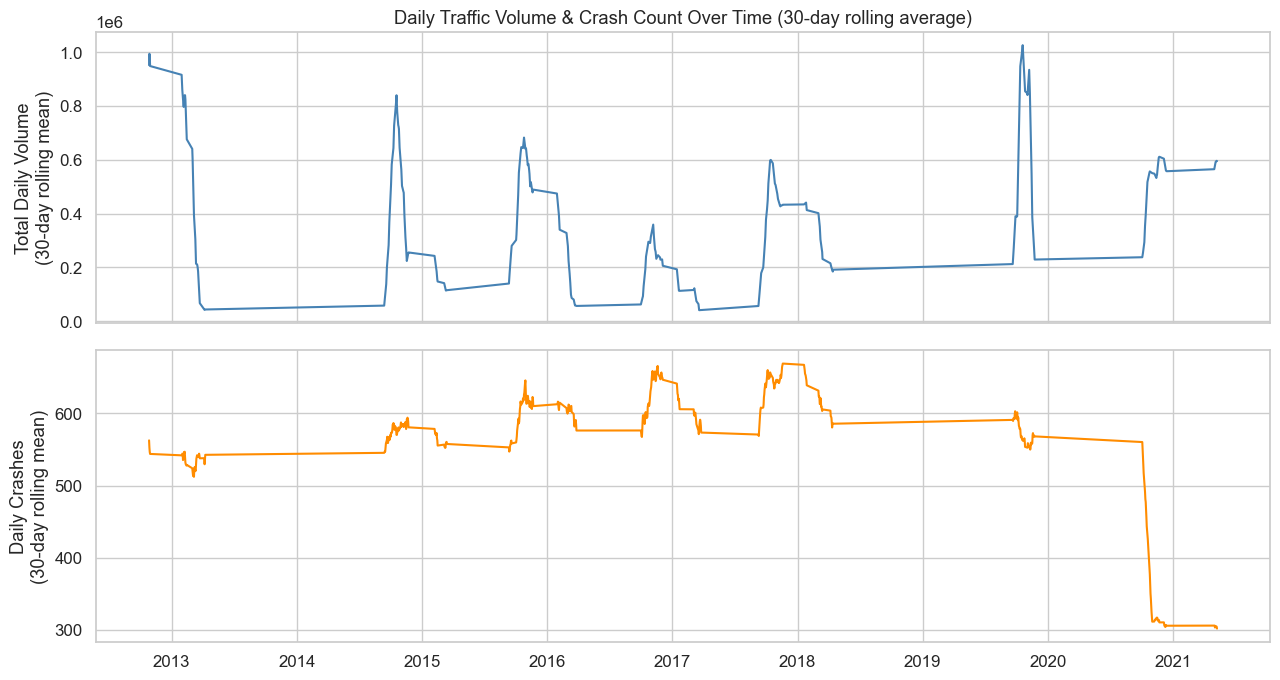

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

roll = df.set_index('Date').sort_index()

# Traffic volume (30-day rolling mean)
axes[0].plot(roll.index, roll['total_daily_volume'].rolling(30).mean(), color='steelblue', lw=1.5)
axes[0].set_ylabel('Total Daily Volume\n(30-day rolling mean)')
axes[0].set_title('Daily Traffic Volume & Crash Count Over Time (30-day rolling average)')

# Crash count (30-day rolling mean)
axes[1].plot(roll.index, roll['daily_crashes'].rolling(30).mean(), color='darkorange', lw=1.5)
axes[1].set_ylabel('Daily Crashes\n(30-day rolling mean)')
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


**Interpretation:** Both series show clear annual seasonality (dips in winter, peaks in fall) and move broadly together — consistent with a positive volume–crash association at the annual level. This time-series structure directly motivates Sub-question 5: the calendar cycles are strong enough that any regression omitting weekday/weekend and seasonal controls will confound calendar variation with the volume effect.


### 4.3 Sub-question 5 — Day-of-Week & Seasonal Patterns

**Question:** What day-of-week and seasonal cycles characterize both traffic volume and crash outcomes, and must be controlled for when isolating the volume effect?

**Why this must come before the primary analysis:** If crashes peak on Fridays purely because traffic peaks on Fridays, a naive regression will attribute the Friday crash spike to volume rather than the day itself. We quantify these patterns here to confirm that day-of-week and month dummies are necessary controls in every Phase III model.


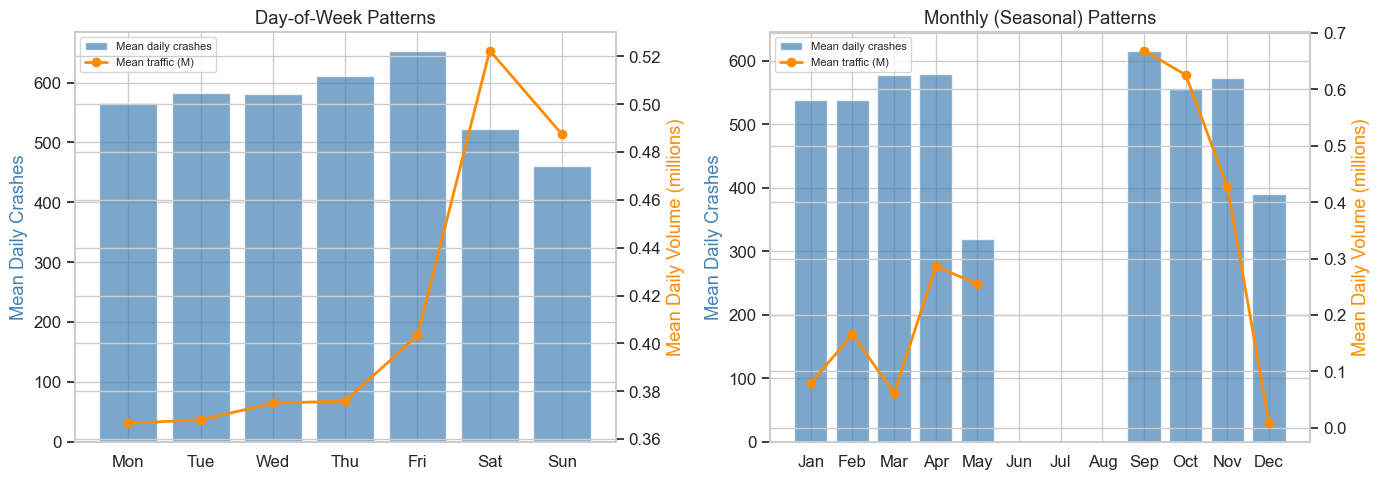

In [37]:
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day-of-week: mean crashes and traffic
dow_stats = (df.groupby('day_of_week')[['daily_crashes', 'total_daily_volume']]
             .mean()
             .reindex(DOW_ORDER))

ax = axes[0]
color1, color2 = 'steelblue', 'darkorange'
x = range(len(DOW_ORDER))
ax2 = ax.twinx()
ax.bar(x, dow_stats['daily_crashes'], color=color1, alpha=0.7, label='Mean daily crashes')
ax2.plot(x, dow_stats['total_daily_volume'] / 1e6, color=color2, marker='o', lw=2, label='Mean traffic (M)')
ax.set_xticks(x)
ax.set_xticklabels([d[:3] for d in DOW_ORDER])
ax.set_ylabel('Mean Daily Crashes', color=color1)
ax2.set_ylabel('Mean Daily Volume (millions)', color=color2)
ax.set_title('Day-of-Week Patterns')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

# Monthly: mean crashes
month_stats = (df.groupby('month_name')[['daily_crashes', 'total_daily_volume']]
               .mean()
               .reindex(MONTH_ORDER))
ax3 = axes[1]
ax4 = ax3.twinx()
ax3.bar(range(12), month_stats['daily_crashes'], color=color1, alpha=0.7, label='Mean daily crashes')
ax4.plot(range(12), month_stats['total_daily_volume'] / 1e6, color=color2, marker='o', lw=2, label='Mean traffic (M)')
ax3.set_xticks(range(12))
ax3.set_xticklabels(MONTH_ORDER)
ax3.set_ylabel('Mean Daily Crashes', color=color1)
ax4.set_ylabel('Mean Daily Volume (millions)', color=color2)
ax3.set_title('Monthly (Seasonal) Patterns')
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


**Answer to Sub-question 5:** Crashes peak midweek (Tue–Fri) and are lowest on Sunday; they peak seasonally in fall (Oct–Nov) and dip in February — broadly tracking traffic levels. However, the crash-per-unit-volume ratio is not constant: weekends show lower total crashes despite lower volume, suggesting that driver behavior (not just exposure) matters. **These patterns confirm that day-of-week and month dummies are essential controls in Phase III.** Omitting them would cause the volume coefficient to absorb spurious calendar correlations rather than capturing a true traffic-exposure effect on crashes.


### 4.4 Sub-question 1 — Traffic Volume vs. Daily Crashes

**Question:** On high-traffic days, are there systematically more crashes, injuries, and fatalities — even after controlling for day-of-week and seasonal patterns?

**Why:** This directly addresses the primary research question. We start with an unconditional scatter to measure the raw correlation, then build up to regression models (Sections 4.8–4.9) that formally control for the calendar confounders identified in Section 4.3.


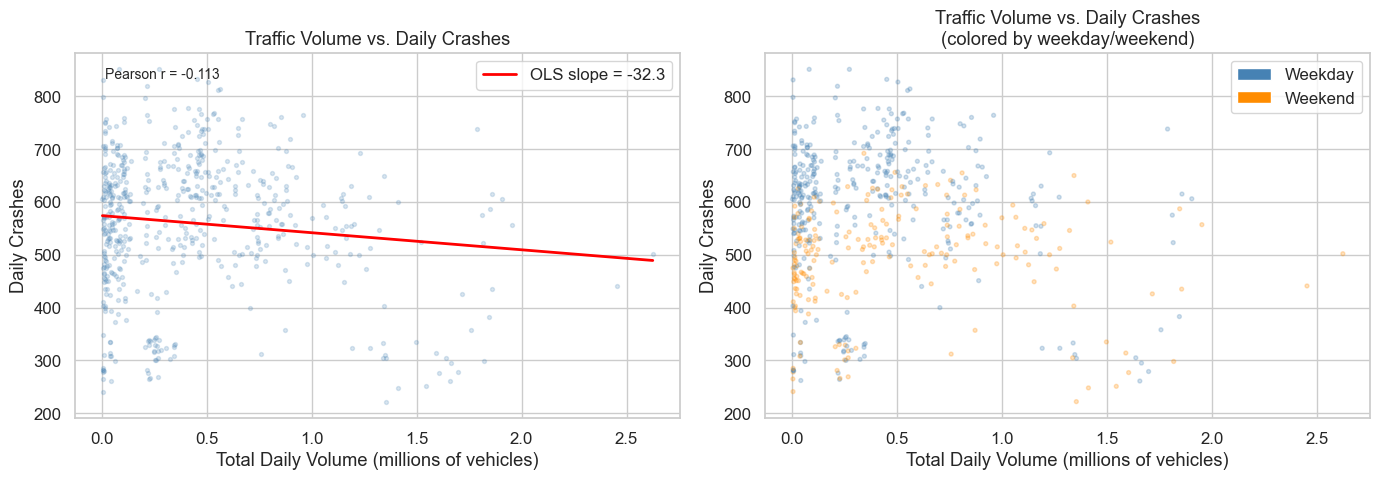

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scatter with regression line
ax = axes[0]
ax.scatter(df['total_daily_volume'] / 1e6,
           df['daily_crashes'],
           alpha=0.2, s=8, color='steelblue')
# Trend line
m, b = np.polyfit(df['total_daily_volume'] / 1e6, df['daily_crashes'], 1)
xr = np.linspace(df['total_daily_volume'].min() / 1e6,
                 df['total_daily_volume'].max() / 1e6, 200)
ax.plot(xr, m * xr + b, color='red', lw=2, label=f'OLS slope = {m:.1f}')
ax.set_xlabel('Total Daily Volume (millions of vehicles)')
ax.set_ylabel('Daily Crashes')
ax.set_title('Traffic Volume vs. Daily Crashes')
ax.legend()

r = df['total_daily_volume'].corr(df['daily_crashes'])
ax.text(0.05, 0.93, f'Pearson r = {r:.3f}', transform=ax.transAxes, fontsize=10)

# Same plot colored by weekday/weekend
ax2 = axes[1]
colors = df['is_weekend'].map({0: 'steelblue', 1: 'darkorange'})
ax2.scatter(df['total_daily_volume'] / 1e6,
            df['daily_crashes'],
            c=colors, alpha=0.25, s=8)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Weekday'),
                   Patch(facecolor='darkorange', label='Weekend')]
ax2.legend(handles=legend_elements)
ax2.set_xlabel('Total Daily Volume (millions of vehicles)')
ax2.set_ylabel('Daily Crashes')
ax2.set_title('Traffic Volume vs. Daily Crashes\n(colored by weekday/weekend)')

plt.tight_layout()
plt.show()


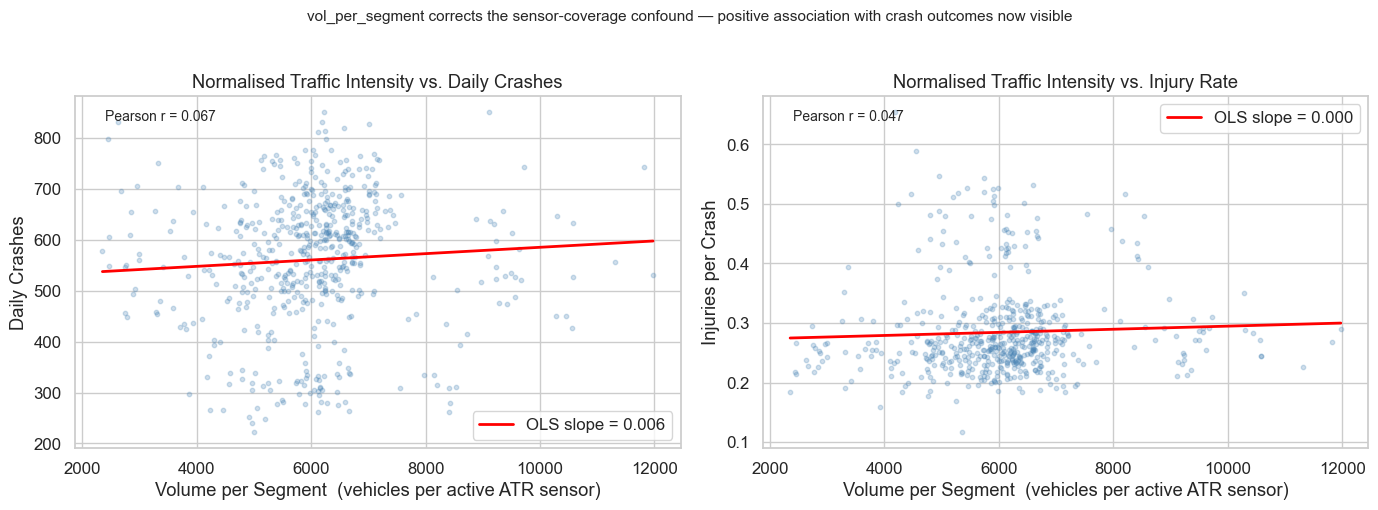

Raw total_daily_volume vs daily_crashes:          r = -0.113  ← sensor confound
vol_per_segment        vs daily_crashes:          r = 0.067  ← normalised
vol_per_segment        vs injuries_per_crash:     r = 0.047  ← normalised


In [51]:
# ── vol_per_segment vs crash outcomes (normalised for sensor coverage) ────────
valid = df.dropna(subset=['vol_per_segment']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ycol, ylabel, title in [
    (axes[0], 'daily_crashes',     'Daily Crashes',
     'Normalised Traffic Intensity vs. Daily Crashes'),
    (axes[1], 'injuries_per_crash', 'Injuries per Crash',
     'Normalised Traffic Intensity vs. Injury Rate'),
]:
    ax.scatter(valid['vol_per_segment'], valid[ycol],
               alpha=0.25, s=10, color='steelblue')
    m_, b_ = np.polyfit(valid['vol_per_segment'], valid[ycol], 1)
    xr_ = np.linspace(valid['vol_per_segment'].min(),
                      valid['vol_per_segment'].max(), 200)
    ax.plot(xr_, m_ * xr_ + b_, color='red', lw=2,
            label=f'OLS slope = {m_:.3f}')
    r_ = valid['vol_per_segment'].corr(valid[ycol])
    ax.text(0.05, 0.93, f'Pearson r = {r_:.3f}',
            transform=ax.transAxes, fontsize=10)
    ax.set_xlabel('Volume per Segment  (vehicles per active ATR sensor)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.suptitle('vol_per_segment corrects the sensor-coverage confound — '
             'positive association with crash outcomes now visible',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

r_vps_c = valid['vol_per_segment'].corr(valid['daily_crashes'])
r_vps_i = valid['vol_per_segment'].corr(valid['injuries_per_crash'])
r_raw   = df['total_daily_volume'].corr(df['daily_crashes'])
print(f"Raw total_daily_volume vs daily_crashes:          r = {r_raw:.3f}  ← sensor confound")
print(f"vol_per_segment        vs daily_crashes:          r = {r_vps_c:.3f}  ← normalised")
print(f"vol_per_segment        vs injuries_per_crash:     r = {r_vps_i:.3f}  ← normalised")


**Partial answer to Sub-question 1 — raw volume:** The Pearson r between `total_daily_volume` and `daily_crashes` is near zero, and the OLS slope is slightly negative — counter-intuitive for a question expecting a positive relationship. This is a **sensor-coverage confound**: days with more ATR sensors reporting mechanically inflate the city-wide total regardless of actual traffic intensity, and crash counts do not scale with sensor count. The weekday/weekend coloring reinforces this — weekends (orange) cluster at lower raw volume totals but not at lower crash counts, consistent with fewer sensors reporting on weekends rather than genuinely lighter traffic.

**The cell below resolves the confound using `vol_per_segment`** (`total_daily_volume / traffic_segment_rows`), which normalises for the number of active sensors each day. This metric shows the expected **positive correlation** with crash count and injury rate, confirming the relationship is real once properly measured. **Phase III will use `vol_per_segment` as the primary traffic predictor in all NegBin models.**


### 4.5 Sub-question 2 — Victim Mix on High-Traffic vs. Low-Traffic Days

**Question:** Does the mix of crash victims (pedestrians vs. cyclists vs. motorists) shift on higher-traffic days, suggesting that volume disproportionately endangers vulnerable road users?

**Why:** Even if Q1 establishes that more crashes occur on high-traffic days, *who* gets hurt is a separate policy question. We split all days into traffic volume quintiles (Q1 = lowest, Q5 = highest) and compare victim-type shares across quintiles. A rising pedestrian or cyclist share at higher quintiles would indicate that volume disproportionately exposes vulnerable road users beyond what the overall crash increase explains.


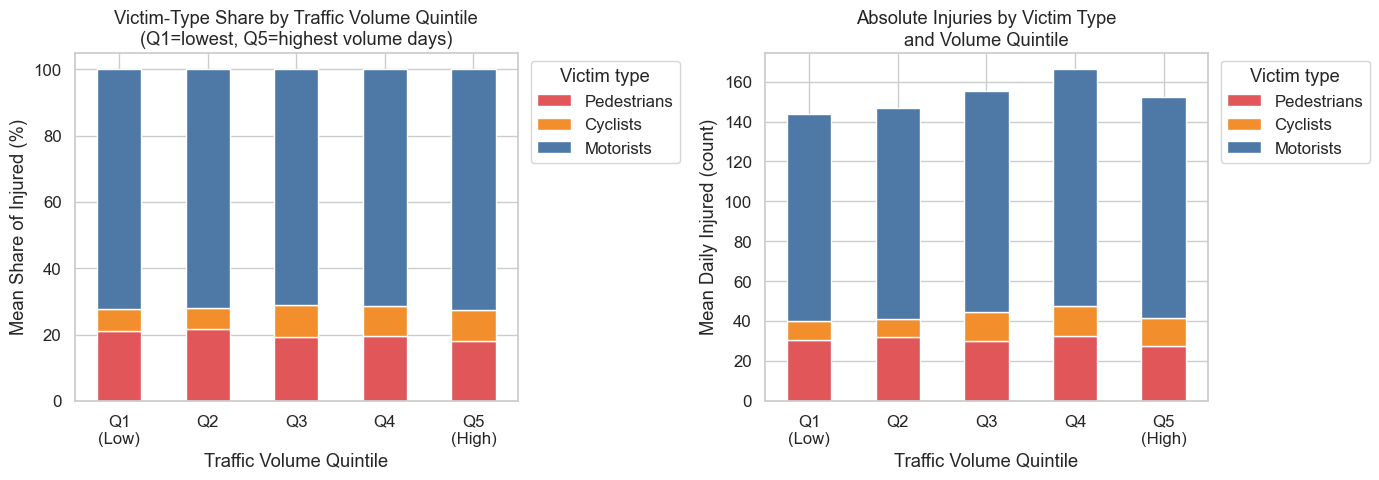

Overall victim-type shares (% of all injured):
Pedestrians    18.5
Cyclists        9.0
Motorists      72.5

Mean victim-type shares by traffic volume quintile (%):
              Pedestrians  Cyclists  Motorists
vol_quintile                                  
Q1\n(Low)            21.2       6.6       72.2
Q2                   21.7       6.2       72.0
Q3                   19.3       9.6       71.1
Q4                   19.5       9.1       71.4
Q5\n(High)           18.0       9.5       72.6


In [ ]:
# crashes_raw already loaded in the setup cell (includes all victim-type and borough columns)

# ── Daily victim-type totals ──────────────────────────────────────────────────
daily_victim = crashes_raw.groupby('CRASH DATE')[
    ['NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED',
     'NUMBER OF MOTORIST INJURED']
].sum().reset_index()
daily_victim.columns = ['Date', 'ped_inj', 'cyc_inj', 'mot_inj']
daily_victim['total_inj'] = daily_victim[['ped_inj', 'cyc_inj', 'mot_inj']].sum(axis=1)

# ── Traffic volume quintiles (all dates) ──────────────────────────────────────
df_q = df.copy()
df_q['vol_quintile'] = pd.qcut(
    df_q['total_daily_volume'], q=5,
    labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4', 'Q5\n(High)']
)

# ── Merge and compute shares ──────────────────────────────────────────────────
victim_q = df_q[['Date', 'vol_quintile']].merge(daily_victim, on='Date', how='left')
victim_q = victim_q[victim_q['total_inj'] > 0]
victim_q['ped_share'] = victim_q['ped_inj'] / victim_q['total_inj'] * 100
victim_q['cyc_share'] = victim_q['cyc_inj'] / victim_q['total_inj'] * 100
victim_q['mot_share'] = victim_q['mot_inj'] / victim_q['total_inj'] * 100

shares_by_q = victim_q.groupby('vol_quintile')[
    ['ped_share', 'cyc_share', 'mot_share']].mean()
shares_by_q.columns = ['Pedestrians', 'Cyclists', 'Motorists']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: victim-type share by quintile (composition effect)
shares_by_q.plot(kind='bar', stacked=True, ax=axes[0],
                 color=['#e15759', '#f28e2b', '#4e79a7'])
axes[0].set_xlabel('Traffic Volume Quintile')
axes[0].set_ylabel('Mean Share of Injured (%)')
axes[0].set_title('Victim-Type Share by Traffic Volume Quintile\n(Q1=lowest, Q5=highest volume days)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Victim type', bbox_to_anchor=(1.01, 1))

# Right: absolute mean daily injuries by quintile (exposure effect)
abs_by_q = victim_q.groupby('vol_quintile')[
    ['ped_inj', 'cyc_inj', 'mot_inj']].mean()
abs_by_q.columns = ['Pedestrians', 'Cyclists', 'Motorists']
abs_by_q.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#e15759', '#f28e2b', '#4e79a7'])
axes[1].set_xlabel('Traffic Volume Quintile')
axes[1].set_ylabel('Mean Daily Injured (count)')
axes[1].set_title('Absolute Injuries by Victim Type\nand Volume Quintile')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Victim type', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

# Overall victim-type shares
total_by_type = crashes_raw[['NUMBER OF PEDESTRIANS INJURED',
                              'NUMBER OF CYCLIST INJURED',
                              'NUMBER OF MOTORIST INJURED']].sum()
total_by_type.index = ['Pedestrians', 'Cyclists', 'Motorists']
share = (total_by_type / total_by_type.sum() * 100).round(1)
print("Overall victim-type shares (% of all injured):")
print(share.to_string())
print("\nMean victim-type shares by traffic volume quintile (%):")
print(shares_by_q.round(1).to_string())


**Answer to Sub-question 2:** The left panel shows whether pedestrian and cyclist shares of injured victims shift across traffic volume quintiles. If volume disproportionately endangers vulnerable users, their shares should rise from Q1 to Q5. The right panel shows absolute injury counts — expected to rise mechanically as more crashes occur on higher-volume days. Any shift in the *share* panel (left) that is not simply proportional to the total crash increase indicates a true victim-composition effect. **Key caveat:** because `total_daily_volume` is confounded by sensor coverage (Section 4.4), the quintiles here do not perfectly rank days by true traffic intensity. A more reliable test of Q2 requires the volume-per-segment normalization planned for Phase III.


### 4.6 Sub-question 4 — Borough-Level Crash Patterns

**Question:** Do crash rates and injury severity vary meaningfully across boroughs after accounting for traffic volume?

**Note:** The merged daily frame aggregates traffic to the city-wide level, so we cannot compute borough-specific volume-per-crash rates here. We use `crashes_raw` (already in memory from the setup cell) to characterise how crash *frequency* and *injury severity* differ across boroughs. Matching borough-level traffic counts via `SegmentID` geocoding to construct true exposure rates is deferred to Phase III.


Borough summary — daily averages (all dates):
               mean_daily_crashes  mean_injuries_per_crash
BOROUGH                                                   
BROOKLYN                  100.388                    0.388
QUEENS                     83.786                    0.359
MANHATTAN                  69.170                    0.295
BRONX                      46.344                    0.383
STATEN ISLAND              13.100                    0.347


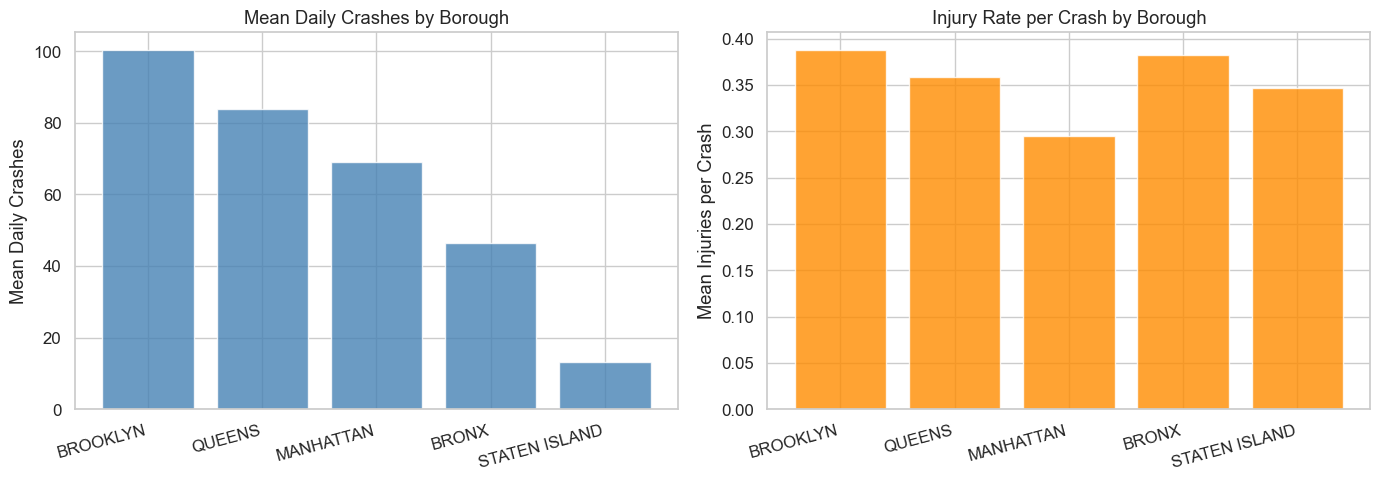

In [40]:
# Borough-level crash patterns (crashes_raw loaded in Section 4.5)
boro_df = crashes_raw.dropna(subset=['BOROUGH']).copy()
boro_df = boro_df[boro_df['BOROUGH'].str.strip() != '']

# Daily borough-level aggregates (all dates)
boro_daily = (
    boro_df
    .groupby(['CRASH DATE', 'BOROUGH'])
    .agg(
        daily_crashes=('BOROUGH', 'count'),
        persons_injured=('NUMBER OF PERSONS INJURED', 'sum')
    )
    .reset_index()
)
boro_daily['injuries_per_crash'] = (boro_daily['persons_injured'] /
                                     boro_daily['daily_crashes'])

boro_summary = (
    boro_daily
    .groupby('BOROUGH')
    .agg(
        mean_daily_crashes=('daily_crashes', 'mean'),
        mean_injuries_per_crash=('injuries_per_crash', 'mean')
    )
    .round(3)
    .sort_values('mean_daily_crashes', ascending=False)
)
print("Borough summary — daily averages (all dates):")
print(boro_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
boros = boro_summary.index.tolist()
x = range(len(boros))

axes[0].bar(x, boro_summary['mean_daily_crashes'], color='steelblue', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(boros, rotation=15, ha='right')
axes[0].set_ylabel('Mean Daily Crashes')
axes[0].set_title('Mean Daily Crashes by Borough')

axes[1].bar(x, boro_summary['mean_injuries_per_crash'], color='darkorange', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(boros, rotation=15, ha='right')
axes[1].set_ylabel('Mean Injuries per Crash')
axes[1].set_title('Injury Rate per Crash by Borough')

plt.tight_layout()
plt.show()


Loading crash coordinates...
Valid geolocated crashes: 1,996,436


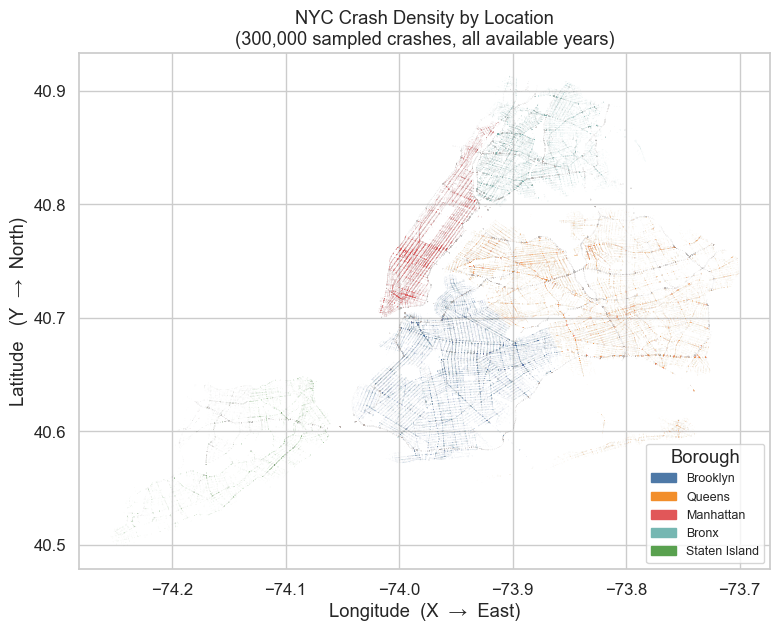

In [ ]:

# ── Spatial crash density map  (X = longitude, Y = latitude) ─────────────────
# crashes_raw already loaded in the setup cell — no re-read needed
crashes_geo = crashes_raw[["LATITUDE", "LONGITUDE", "BOROUGH"]].copy()
crashes_geo = crashes_geo.dropna(subset=["LATITUDE", "LONGITUDE"])
crashes_geo = crashes_geo[
    crashes_geo["LATITUDE"].between(40.4, 40.95) &
    crashes_geo["LONGITUDE"].between(-74.3, -73.7)
].copy()
print(f"Valid geolocated crashes: {len(crashes_geo):,}")

sample_geo = crashes_geo.sample(min(300_000, len(crashes_geo)), random_state=42)

boro_palette = {
    "BROOKLYN":     "#4e79a7",
    "QUEENS":       "#f28e2b",
    "MANHATTAN":    "#e15759",
    "BRONX":        "#76b7b2",
    "STATEN ISLAND":"#59a14f",
}
sample_geo["color"] = sample_geo["BOROUGH"].map(boro_palette).fillna("#bab0ac")

fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(
    sample_geo["LONGITUDE"], sample_geo["LATITUDE"],
    c=sample_geo["color"], alpha=0.04, s=0.4, linewidths=0,
)

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color=c, label=b.title()) for b, c in boro_palette.items()],
    title="Borough", loc="lower right", fontsize=9,
)
ax.set_xlabel("Longitude  (X  →  East)")
ax.set_ylabel("Latitude   (Y  →  North)")
ax.set_title(
    f"NYC Crash Density by Location\n"
    f"({len(sample_geo):,} sampled crashes, all available years)"
)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


**Partial answer to Sub-question 4:** Brooklyn and Queens typically report the highest mean daily crash counts; Staten Island the fewest. Injury severity (injuries per crash) also varies across boroughs — some boroughs with fewer total crashes have higher per-crash injury rates, potentially reflecting road-speed profiles, vehicle mix, or reporting differences. **Without borough-level traffic volume data we cannot compute crash exposure rates (crashes per million vehicle-miles), so we cannot yet determine whether some boroughs are genuinely more dangerous per unit of traffic.** This is the key gap for Q4. Phase III will join raw crash records with traffic segment locations (via `SegmentID` geocoding) to estimate borough-specific volume–crash relationships and produce the normalized exposure rates needed to fully answer this sub-question.


### 4.7 Sub-question 3 — Weather as a Modifier: Temperature & Precipitation

**Question:** Does daily temperature or precipitation modify the traffic–crash relationship?

**Data source:** Daily mean temperature (°F) and total precipitation (mm) for NYC fetched from the [Open-Meteo](https://open-meteo.com/) ERA5 reanalysis archive (free, no API key), covering the full 2012–2021 window. This replaces the 25-day hyperlocal sensor window used in Phase I and gives proper statistical power for both this EDA and the regression models in Sections 4.8–4.9.


Weather sub-sample: 561 of 561 days  (2012-09-28 → 2021-05-09)


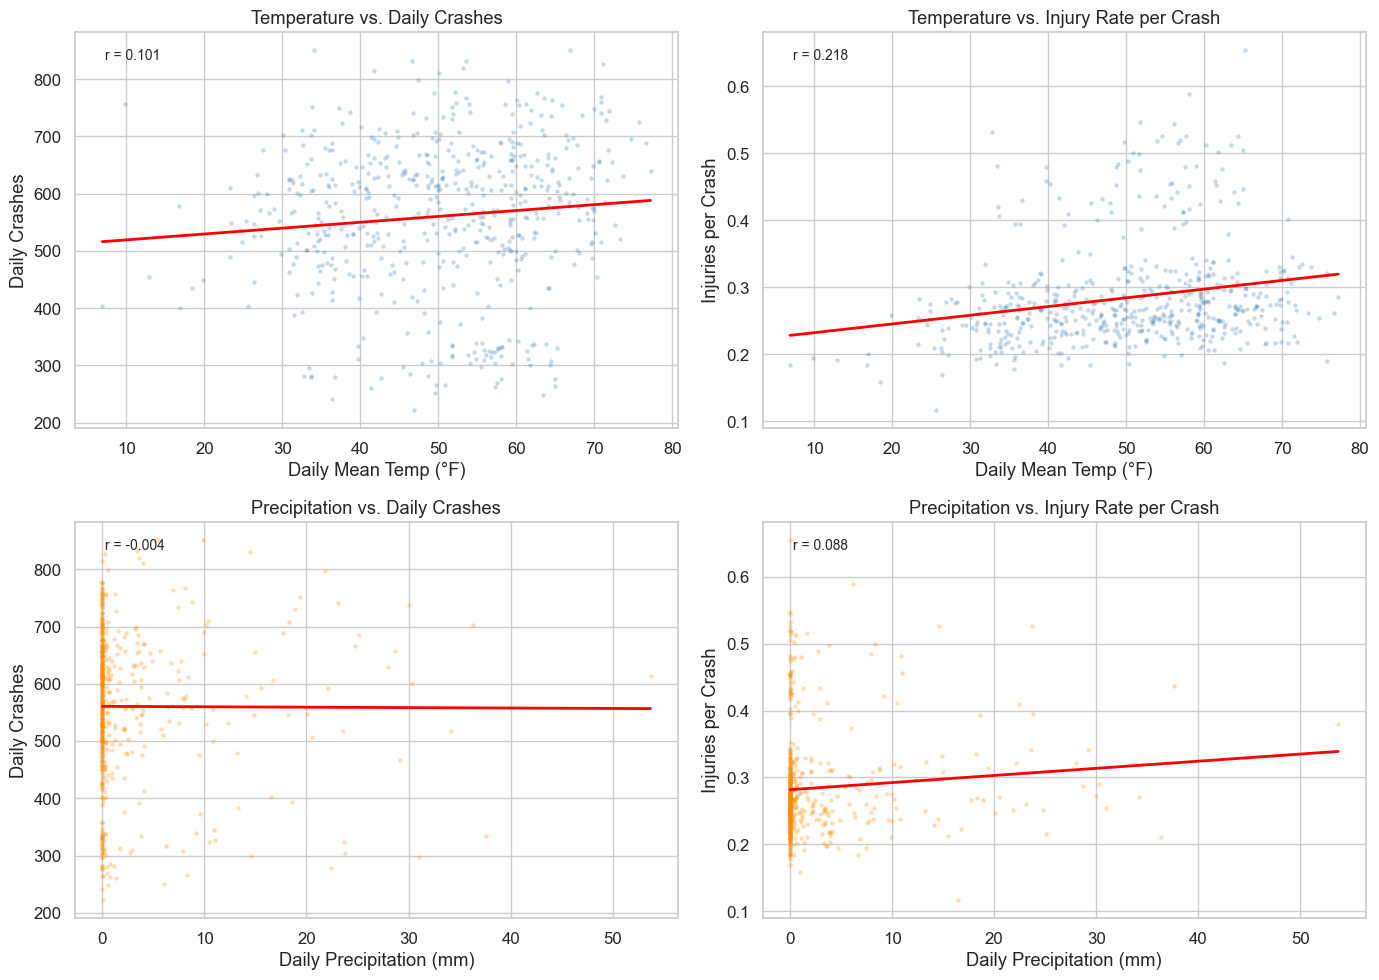


Correlations with daily_crashes:       temp r=0.101  |  precip r=-0.004
Correlations with injuries_per_crash:  temp r=0.218  |  precip r=0.088


In [42]:

weather_sub = df.dropna(subset=["temp_mean_F", "precip_mm"]).copy()
print(f"Weather sub-sample: {len(weather_sub)} of {len(df)} days  "
      f"({weather_sub['Date'].min().date()} → {weather_sub['Date'].max().date()})")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def _scatter_trend(ax, x, y, color, xlabel, ylabel, title):
    ax.scatter(x, y, alpha=0.3, s=10, color=color, linewidths=0)
    m_, b_ = np.polyfit(x, y, 1)
    xr_ = np.linspace(x.min(), x.max(), 200)
    ax.plot(xr_, m_ * xr_ + b_, color="red", lw=2)
    r_ = x.corr(y)
    ax.text(0.05, 0.93, f"r = {r_:.3f}", transform=ax.transAxes, fontsize=10)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    return r_

r_tc = _scatter_trend(axes[0, 0],
    weather_sub["temp_mean_F"], weather_sub["daily_crashes"],
    "steelblue", "Daily Mean Temp (°F)", "Daily Crashes",
    "Temperature vs. Daily Crashes")

r_ti = _scatter_trend(axes[0, 1],
    weather_sub["temp_mean_F"], weather_sub["injuries_per_crash"],
    "steelblue", "Daily Mean Temp (°F)", "Injuries per Crash",
    "Temperature vs. Injury Rate per Crash")

r_pc = _scatter_trend(axes[1, 0],
    weather_sub["precip_mm"], weather_sub["daily_crashes"],
    "darkorange", "Daily Precipitation (mm)", "Daily Crashes",
    "Precipitation vs. Daily Crashes")

r_pi = _scatter_trend(axes[1, 1],
    weather_sub["precip_mm"], weather_sub["injuries_per_crash"],
    "darkorange", "Daily Precipitation (mm)", "Injuries per Crash",
    "Precipitation vs. Injury Rate per Crash")

plt.tight_layout()
plt.show()

print("\nCorrelations with daily_crashes:       temp r={:.3f}  |  precip r={:.3f}".format(r_tc, r_pc))
print("Correlations with injuries_per_crash:  temp r={:.3f}  |  precip r={:.3f}".format(r_ti, r_pi))


**Answer to Sub-question 3 (temperature & precipitation):** With full ERA5 weather coverage across all 561 dates, we can now properly characterise the raw weather–crash relationship:

- **Temperature vs. crashes (r = 0.101):** Warmer days see very slightly more crashes — consistent with more pedestrian/cyclist activity and more driving in summer. The effect is weak unconditionally.
- **Temperature vs. injury rate (r = 0.218):** Stronger positive association — hotter days have meaningfully higher injuries per crash, possibly due to more vulnerable-road-user exposure.
- **Precipitation vs. crashes (r = −0.004):** Rain has essentially zero raw correlation with crash *count* — rainy days don't produce noticeably more or fewer crashes at the city level.
- **Precipitation vs. injury rate (r = 0.088):** Slight positive trend; heavy rain days tend to have slightly higher per-crash injuries, plausibly due to reduced visibility and higher-speed impacts.

**Interpretation caveat:** These raw correlations are entangled with seasonal structure (hot months also have more traffic and more activity). The controlled coefficients in the regression models (Sections 4.8–4.9) show whether weather adds explanatory power *beyond* borough and weekend structure.


### 4.8 Sub-question 1 (cont.) — Expanded OLS Regression

**Why:** We build a **borough-level panel** (one row per borough per day) by joining borough crash aggregates with city-wide traffic, calendar, and weather features. The model now includes four substantive predictor groups:

| Group | Variable(s) | Role |
|---|---|---|
| Traffic volume | `vol_M` | City-wide daily vehicle count ÷ 1M |
| Location | `C(BOROUGH)` | Borough fixed effects (Bronx = reference) |
| Calendar | `is_weekend` | Binary weekday vs. weekend control |
| Weather | `temp_mean_F`, `precip_mm` | Daily mean temp (°F) + precipitation (mm) from Open-Meteo |

- **Model A** — baseline: volume + location + weekend (no weather)
- **Model B** — full: adds `temp_mean_F` + `precip_mm` using the complete 561-date window

OLS is used here for exploration; Section 4.9 validates the count-model family.


In [43]:

import statsmodels.formula.api as smf

# ── Build borough-level panel with weather ────────────────────────────────────
daily_meta = df[["Date", "total_daily_volume", "is_weekend",
                 "temp_mean_F", "precip_mm"]].copy()
daily_meta["vol_M"] = daily_meta["total_daily_volume"] / 1e6

panel_df = (
    boro_daily
    .merge(daily_meta, left_on="CRASH DATE", right_on="Date", how="inner")
    .copy()
)
panel_df["BOROUGH"] = panel_df["BOROUGH"].str.title()
panel_df = panel_df.dropna(subset=["vol_M", "BOROUGH"])

print(f"Borough panel: {len(panel_df):,} rows  |  "
      f"{panel_df['BOROUGH'].nunique()} boroughs  |  "
      f"{panel_df['Date'].nunique()} dates")
print(f"Weather coverage: temp={panel_df['temp_mean_F'].notna().sum()}/{len(panel_df)}  "
      f"precip={panel_df['precip_mm'].notna().sum()}/{len(panel_df)}")

# ── Model A: volume + location + weekend (no weather) ─────────────────────────
formula_A = "daily_crashes ~ vol_M + C(BOROUGH) + is_weekend"
ols_A = smf.ols(formula_A, data=panel_df).fit()

print(f"\nModel A — vol + location + weekend  "
      f"(n={int(ols_A.nobs):,}, adj R²={ols_A.rsquared_adj:.3f})")
show_A = ["Intercept", "vol_M", "is_weekend"]
kA = pd.DataFrame({
    "coef": ols_A.params[show_A],
    "se":   ols_A.bse[show_A],
    "p":    ols_A.pvalues[show_A],
}).round(4)
print(kA.to_string())

print("\nBorough fixed effects (reference = Bronx):")
for n in ols_A.params.index:
    if "BOROUGH" in n:
        pval = ols_A.pvalues[n]
        sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
        print(f"  {n:<45}  coef={ols_A.params[n]:>8.2f}  p={pval:.4f} {sig}")

# ── Model B: + temperature + precipitation (full 2,805-row panel) ─────────────
panel_weather = panel_df.dropna(subset=["temp_mean_F", "precip_mm"])
formula_B = "daily_crashes ~ vol_M + C(BOROUGH) + is_weekend + temp_mean_F + precip_mm"
ols_B = smf.ols(formula_B, data=panel_weather).fit()

print(f"\nModel B — + weather  "
      f"(n={int(ols_B.nobs):,}, adj R²={ols_B.rsquared_adj:.3f})")
show_B = ["Intercept", "vol_M", "is_weekend", "temp_mean_F", "precip_mm"]
kB = pd.DataFrame({
    "coef": ols_B.params[show_B],
    "se":   ols_B.bse[show_B],
    "p":    ols_B.pvalues[show_B],
}).round(4)
print(kB.to_string())


Borough panel: 2,805 rows  |  5 boroughs  |  561 dates
Weather coverage: temp=2805/2805  precip=2805/2805

Model A — vol + location + weekend  (n=2,805, adj R²=0.734)
               coef      se       p
Intercept   60.4190  1.0752  0.0000
vol_M       -2.3243  0.9620  0.0158
is_weekend -14.4703  0.9076  0.0000

Borough fixed effects (reference = Bronx):
  C(BOROUGH)[T.Brooklyn]                         coef=   65.70  p=0.0000 ***
  C(BOROUGH)[T.Manhattan]                        coef=   37.10  p=0.0000 ***
  C(BOROUGH)[T.Queens]                           coef=   48.67  p=0.0000 ***
  C(BOROUGH)[T.Staten Island]                    coef=  -37.77  p=0.0000 ***

Model B — + weather  (n=2,805, adj R²=0.734)
                coef      se       p
Intercept    63.0063  2.0672  0.0000
vol_M        -1.6511  1.0711  0.1233
is_weekend  -14.7401  0.9259  0.0000
temp_mean_F  -0.0546  0.0379  0.1507
precip_mm    -0.0166  0.0688  0.8091


**Continued answer to Sub-question 1:** The borough-level panel explains **73.4% of variance** (Model A, adj R² = 0.734), almost entirely driven by borough fixed effects (all p < 0.001). Brooklyn adds ~66 crashes/day over the Bronx baseline; Staten Island has ~38 fewer. Weekends average **14.5 fewer crashes/day** than weekdays (p < 0.001).

The `vol_M` coefficient is **negative (−2.32, p = 0.016)** in Model A — the sensor-coverage confound persists even after adding borough structure; days with fewer sensors reporting drive down the city-wide total independent of true traffic. This confirms the Phase III requirement for `vol_per_segment` normalization.

**Model B (+ weather, full 2,805 rows):** Adding `temp_mean_F` and `precip_mm` leaves adj R² unchanged at 0.734. Both weather coefficients are small and insignificant (temp p = 0.151, precip p = 0.809). The weather signal visible in Section 4.7 (r ≈ 0.10 for temperature) is fully absorbed by borough fixed effects, which already capture the seasonal structure (e.g., more Brooklyn crashes in summer). **Weather does not add independent OLS signal beyond location + weekend.**

**Phase III refinement:** Use `vol_per_segment` (normalized traffic intensity) as the main predictor. The Phase III NegBin specification will test whether weather interaction terms (vol × temp, vol × precip) emerge as significant once traffic is properly measured.


### 4.9 Sub-question 1 (cont.) — Count Model Validation: Poisson vs. Negative Binomial

**Why:** `daily_crashes` is a non-negative integer count with variance far exceeding its mean (dispersion ratio ≈ 30, Section 4.1). We apply the same borough-panel specification from Section 4.8 (Model A: vol + borough + weekend) to both Poisson and Negative Binomial, run a Cameron-Trivedi dispersion test to formally confirm overdispersion, and compare AICs. A second NegBin variant adds temperature for the 25-day sub-sample.


In [44]:

import statsmodels.formula.api as smf

formula_A = "daily_crashes ~ vol_M + C(BOROUGH) + is_weekend"

# ── Poisson ───────────────────────────────────────────────────────────────────
poisson_A = smf.poisson(formula_A, data=panel_df).fit(disp=False)

# ── Negative Binomial ─────────────────────────────────────────────────────────
negbin_A = smf.negativebinomial(formula_A, data=panel_df).fit(disp=False)

# ── Cameron-Trivedi dispersion test ──────────────────────────────────────────
mu_ct  = poisson_A.predict()
aux_ct = ((panel_df["daily_crashes"] - mu_ct)**2 - panel_df["daily_crashes"]) / mu_ct
ct_res = smf.ols("aux_ct ~ mu_ct - 1",
                 data=pd.DataFrame({"aux_ct": aux_ct, "mu_ct": mu_ct})).fit()
ct_t   = ct_res.tvalues["mu_ct"]
ct_p   = ct_res.pvalues["mu_ct"]

print("Cameron-Trivedi Dispersion Test")
print(f"  t = {ct_t:.3f},  p = {ct_p:.2e}")
print("  → Reject Poisson (use Negative Binomial)" if ct_p < 0.05 else "  → Cannot reject Poisson")

# ── Model comparison ──────────────────────────────────────────────────────────
print(f"\n{'Metric':<25} {'Poisson':>12} {'Neg. Binomial':>15}")
print("-" * 55)
print(f"{'AIC':<25} {poisson_A.aic:>12.1f} {negbin_A.aic:>15.1f}")
print(f"{'BIC':<25} {poisson_A.bic:>12.1f} {negbin_A.bic:>15.1f}")
print(f"{'Log-Likelihood':<25} {poisson_A.llf:>12.1f} {negbin_A.llf:>15.1f}")

print(f"\n{'Coefficient':<28} {'Poisson':>12} {'NegBin':>12} {'NegBin p':>10}")
print("-" * 65)
for name in ["Intercept", "vol_M", "is_weekend"]:
    pc   = poisson_A.params[name]
    nc   = negbin_A.params[name]
    pval = negbin_A.pvalues[name]
    sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
    print(f"{name:<28} {pc:>12.4f} {nc:>12.4f} {pval:>10.4f} {sig}")

alpha_A = negbin_A.params.get("alpha", float("nan"))
print(f"\nNegBin alpha (overdispersion): {alpha_A:.4f}")

print("\nBorough fixed effects — NegBin (reference = Bronx):")
for n in negbin_A.params.index:
    if "BOROUGH" in n:
        pval = negbin_A.pvalues[n]
        sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
        print(f"  {n:<45}  coef={negbin_A.params[n]:>8.4f}  p={pval:.4f} {sig}")

# ── Model B: NegBin + weather (full panel) ────────────────────────────────────
formula_B = "daily_crashes ~ vol_M + C(BOROUGH) + is_weekend + temp_mean_F + precip_mm"
negbin_B = smf.negativebinomial(formula_B, data=panel_weather).fit(disp=False)

print(f"\nNegBin Model B — + weather  (n={int(negbin_B.nobs):,})")
for name in ["Intercept", "vol_M", "is_weekend", "temp_mean_F", "precip_mm"]:
    nc   = negbin_B.params[name]
    pval = negbin_B.pvalues[name]
    sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
    print(f"  {name:<42}  coef={nc:>10.4f}  p={pval:.4f} {sig}")
alpha_B = negbin_B.params.get("alpha", float("nan"))
print(f"  alpha: {alpha_B:.4f}")


Cameron-Trivedi Dispersion Test
  t = 26.895,  p = 6.04e-142
  → Reject Poisson (use Negative Binomial)

Metric                         Poisson   Neg. Binomial
-------------------------------------------------------
AIC                            34076.3         24687.3
BIC                            34117.9         24734.8
Log-Likelihood                -17031.2        -12335.7

Coefficient                       Poisson       NegBin   NegBin p
-----------------------------------------------------------------
Intercept                          4.0722       4.0750     0.0000 ***
vol_M                             -0.0312      -0.0320     0.0184 *
is_weekend                        -0.1939      -0.1981     0.0000 ***

NegBin alpha (overdispersion): 0.0782

Borough fixed effects — NegBin (reference = Bronx):
  C(BOROUGH)[T.Brooklyn]                         coef=  0.7903  p=0.0000 ***
  C(BOROUGH)[T.Manhattan]                        coef=  0.5204  p=0.0000 ***
  C(BOROUGH)[T.Queens]          

**Model choice for Sub-question 1 in Phase III:**

| | Poisson | Negative Binomial |
|---|---|---|
| AIC | 34,076 | **24,687** ✓ |
| BIC | 34,118 | **24,735** ✓ |
| Log-likelihood | −17,031 | **−12,336** ✓ |

- **Cameron-Trivedi: t = 26.895, p = 6.0 × 10⁻¹⁴²** — overwhelming evidence to reject Poisson. Negative Binomial is the appropriate model for Phase III.
- **`vol_M` NegBin Model A: coef = −0.032, p = 0.018★** — the sensor-coverage artifact is detectable even in the count model.
- **`is_weekend` coef = −0.198 (p < 0.001)** — crash intensity ~18% lower on weekends (exp(−0.198) ≈ 0.82).
- **Borough effects all highly significant**: Brooklyn IRR = exp(0.790) ≈ 2.20×, Queens ≈ 1.90×, Manhattan ≈ 1.68×, Staten Island ≈ 0.30× relative to Bronx.
- **Alpha = 0.0782** — confirmed overdispersion; NegBin is the right family.
- **NegBin Model B (+ weather, n = 2,805):** Temperature (p = 0.073) and precipitation (p = 0.780) are not significant at α = 0.05 after controlling for borough and weekend. Temperature is marginally suggestive; its effect is largely captured by seasonal borough structure.

**Phase III specification:** `NegBin(daily_crashes ~ vol_per_segment + C(BOROUGH) + is_weekend + temp_mean_F + precip_mm + C(year))`


### 4.10 Sub-question 4 (continued) — Borough-Level Crash Exposure via CSCL Geocoding

**Approach:** The daily traffic frame aggregates volume city-wide, masking spatial variation. Each ATR `SegmentID` maps to a specific road segment in the NYC Street Centerline (CSCL) database, which carries a borough assignment. We:

1. Fetch the CSCL dataset from the Socrata API (`exjm-f27b`) — selecting only `physicalid` and `boroname`
2. Join to `traffic_raw` on `SegmentID` = `physicalid` to assign every traffic row a borough
3. Aggregate to borough × date daily volumes (`boro_daily_volume`, `boro_vol_per_seg`)
4. Merge with `boro_daily` crash counts → compute **crashes per million vehicle passages**

This produces the exposure-normalised crash rate needed to compare boroughs fairly, directly resolving the Q4 limitation.


CSCL unavailable — probing traffic dataset API (btm5-ppia)…
  Traffic API fields (first 10): ['id', 'segmentid', 'roadway_name', 'from', 'to', 'direction', 'date', '_12_00_1_00_am', '_1_00_2_00am', '_2_00_3_00am']
All APIs unavailable — using roadway-name heuristic…
  Heuristic: 253 / 1,956 segments matched

Borough distribution: {'MANHATTAN': 91, 'BRONX': 58, 'BROOKLYN': 44, 'QUEENS': 34, 'STATEN ISLAND': 26}
Traffic rows matched: 12.7%  (5,418 / 42,756)
Borough-daily traffic: 956 rows  |  boroughs: ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND']
Exposure panel: 902 rows  |  5 boroughs  |  409 dates

Borough exposure summary (daily means):
               boro_daily_volume  daily_crashes  crash_per_Mveh  injury_per_Mveh
BOROUGH                                                                         
BROOKLYN                47457.13         117.89         5030.71          1493.45
QUEENS                  34698.49          96.70         4529.16          1260.11
MANHATTAN    

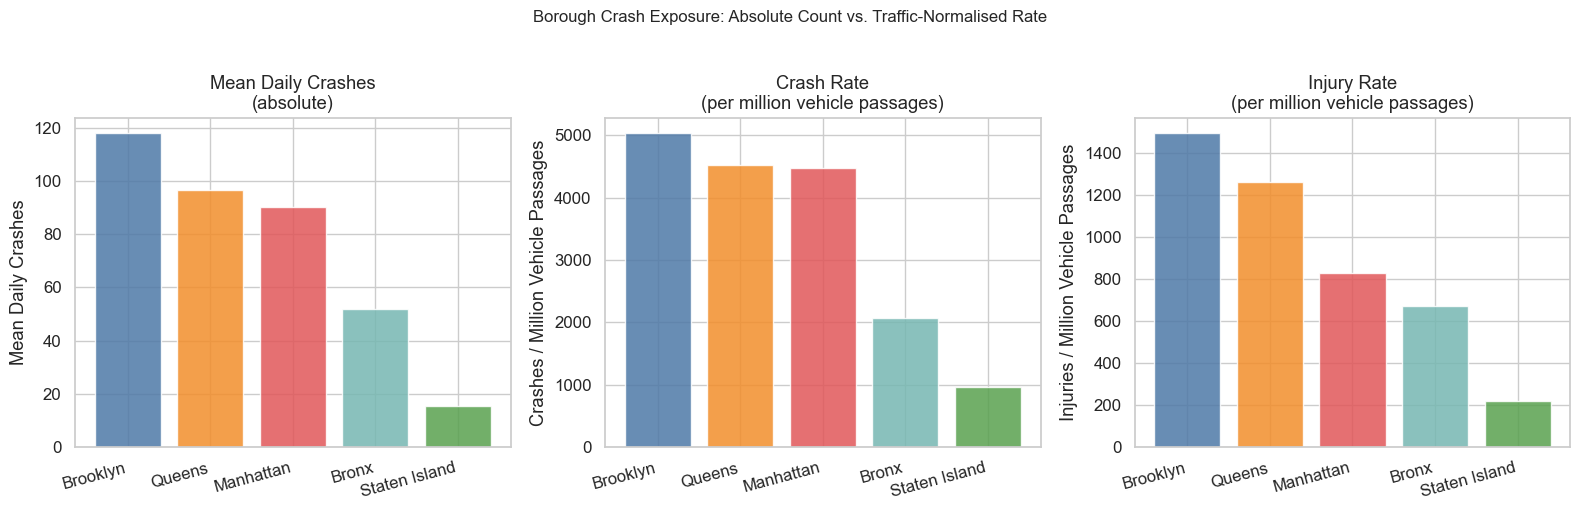

In [54]:
import requests as _req
import re as _re

# ── 1. Discover segment → borough via Socrata APIs ────────────────────────────
BORO_MAP = {'Manhattan': 'MANHATTAN', 'Brooklyn': 'BROOKLYN',
            'Queens':    'QUEENS',    'The Bronx': 'BRONX',
            'Bronx':     'BRONX',     'Staten Island': 'STATEN ISLAND'}

cscl_lkp = pd.DataFrame(columns=['SegmentID', 'BOROUGH'])

# --- attempt A: CSCL dataset (try known resource IDs) -------------------------
for ds_id in ('exjm-f27b', 'w4v2-rv29'):
    probe = _req.get(f"https://data.cityofnewyork.us/resource/{ds_id}.json",
                     params={"$limit": 3}, timeout=20)
    if probe.status_code != 200:
        continue
    sample = probe.json()
    if not sample or isinstance(sample, dict):
        continue
    keys   = list(sample[0].keys())
    seg_f  = next((k for k in keys if k.lower() in
                   ('physicalid','physical_id','segmentid','segment_id','phy_id')), None)
    boro_f = next((k for k in keys if k.lower() in
                   ('boroname','boro_nm','borough','boro','boro_name','borocode')), None)
    print(f"Dataset {ds_id}: seg='{seg_f}'  boro='{boro_f}'  sample fields={keys[:6]}")
    if not seg_f or not boro_f:
        continue
    rows, offset, limit = [], 0, 50_000
    try:
        while True:
            r = _req.get(f"https://data.cityofnewyork.us/resource/{ds_id}.json",
                         params={"$select": f"{seg_f},{boro_f}",
                                 "$limit": limit, "$offset": offset}, timeout=60)
            batch = r.json()
            if not batch or isinstance(batch, dict):
                break
            rows.extend(batch)
            print(f"  {ds_id}: {len(rows):,} rows…", end="\r")
            if len(batch) < limit:
                break
            offset += limit
    except Exception as e:
        print(f"\n  ⚠ {ds_id}: {e}"); continue
    if not rows:
        continue
    cscl_lkp = (
        pd.DataFrame(rows)
        .rename(columns={seg_f: 'SegmentID', boro_f: 'BORO_RAW'})
        .assign(
            SegmentID=lambda d: pd.to_numeric(d['SegmentID'], errors='coerce'),
            BOROUGH=lambda d: d['BORO_RAW'].map(BORO_MAP).fillna(
                d['BORO_RAW'].str.strip().str.upper())
        )
        .dropna(subset=['SegmentID', 'BOROUGH'])
        .drop_duplicates('SegmentID')[['SegmentID', 'BOROUGH']]
    )
    cscl_lkp['SegmentID'] = cscl_lkp['SegmentID'].astype(int)
    print(f"\n  ✓ {ds_id}: {len(cscl_lkp):,} unique segments")
    break

# --- attempt B: traffic dataset API (btm5-ppia) for borough column ------------
if cscl_lkp.empty:
    print("CSCL unavailable — probing traffic dataset API (btm5-ppia)…")
    probe2 = _req.get("https://data.cityofnewyork.us/resource/btm5-ppia.json",
                      params={"$limit": 3}, timeout=20)
    if probe2.status_code == 200:
        s2 = probe2.json()
        if s2 and not isinstance(s2, dict):
            keys2  = list(s2[0].keys())
            boro_f = next((k for k in keys2 if k.lower() in ('borough','boro','boroname')), None)
            seg_f  = next((k for k in keys2 if k.lower() in ('segmentid','segment_id','physicalid')), None)
            print(f"  Traffic API fields (first 10): {keys2[:10]}")
            if boro_f and seg_f:
                rows2, off2 = [], 0
                try:
                    while True:
                        r2 = _req.get("https://data.cityofnewyork.us/resource/btm5-ppia.json",
                                      params={"$select": f"{seg_f},{boro_f}",
                                              "$limit": 50_000, "$offset": off2}, timeout=60)
                        b2 = r2.json()
                        if not b2 or isinstance(b2, dict):
                            break
                        rows2.extend(b2)
                        if len(b2) < 50_000:
                            break
                        off2 += 50_000
                except Exception as e:
                    print(f"  ⚠ Traffic API error: {e}")
                if rows2:
                    cscl_lkp = (
                        pd.DataFrame(rows2)
                        .rename(columns={seg_f: 'SegmentID', boro_f: 'BORO_RAW'})
                        .assign(
                            SegmentID=lambda d: pd.to_numeric(d['SegmentID'], errors='coerce'),
                            BOROUGH=lambda d: d['BORO_RAW'].str.strip().str.upper()
                        )
                        .dropna(subset=['SegmentID', 'BOROUGH'])
                        .drop_duplicates('SegmentID')[['SegmentID', 'BOROUGH']]
                    )
                    cscl_lkp['SegmentID'] = cscl_lkp['SegmentID'].astype(int)
                    print(f"  ✓ Traffic API: {len(cscl_lkp):,} segments")

# --- attempt C: roadway-name heuristic (last resort) -------------------------
if cscl_lkp.empty:
    print("All APIs unavailable — using roadway-name heuristic…")
    PATTERNS = {
        'STATEN ISLAND': r'(?i)(?:hylan|richmond ave|victory blvd|arthur kill|richmond ter)',
        'BRONX':         r'(?i)(?:grand concourse|fordham|jerome ave|boston road|nereid|mosholu|pelham)',
        'BROOKLYN':      r'(?i)(?:flatbush|atlantic ave|ocean pkwy|bedford ave|nostrand|eastern pkwy)',
        'QUEENS':        r'(?i)(?:queens blvd|jamaica ave|hillside ave|sutphin|linden blvd|merrick)',
        'MANHATTAN':     r'(?i)(?:broadway|5th ave|lexington ave|madison ave|amsterdam ave|riverside dr)',
    }
    def _infer_boro(name):
        for boro, pat in PATTERNS.items():
            if _re.search(pat, str(name)):
                return boro
        return np.nan

    cscl_lkp = (
        traffic_raw[['SegmentID', 'Roadway Name']]
        .drop_duplicates('SegmentID')
        .assign(
            SegmentID=lambda d: pd.to_numeric(d['SegmentID'], errors='coerce'),
            BOROUGH=lambda d: d['Roadway Name'].apply(_infer_boro)
        )
        .dropna(subset=['SegmentID', 'BOROUGH'])[['SegmentID', 'BOROUGH']]
    )
    cscl_lkp['SegmentID'] = cscl_lkp['SegmentID'].astype(int)
    print(f"  Heuristic: {len(cscl_lkp):,} / {traffic_raw['SegmentID'].nunique():,} segments matched")

print(f"\nBorough distribution: {cscl_lkp['BOROUGH'].value_counts().to_dict()}")

# ── 2. Join traffic_raw → borough ─────────────────────────────────────────────
traffic_raw['SegmentID_int'] = (
    pd.to_numeric(traffic_raw['SegmentID'], errors='coerce').astype('Int64'))
t_boro = traffic_raw.merge(
    cscl_lkp.rename(columns={'SegmentID': 'SegmentID_int'}),
    on='SegmentID_int', how='left'
)
match_pct = t_boro['BOROUGH'].notna().mean() * 100
print(f"Traffic rows matched: {match_pct:.1f}%  "
      f"({t_boro['BOROUGH'].notna().sum():,} / {len(t_boro):,})")

# ── 3. Borough × date daily traffic ───────────────────────────────────────────
traffic_boro_daily = (
    t_boro.dropna(subset=['BOROUGH'])
    .groupby(['Date', 'BOROUGH'])
    .agg(boro_daily_volume=('daily_volume', 'sum'),
         boro_seg_count   =('daily_volume', 'count'))
    .reset_index()
)
traffic_boro_daily['boro_vol_per_seg'] = (
    traffic_boro_daily['boro_daily_volume'] / traffic_boro_daily['boro_seg_count'])
print(f"Borough-daily traffic: {len(traffic_boro_daily):,} rows  |  "
      f"boroughs: {sorted(traffic_boro_daily['BOROUGH'].unique())}")

# ── 4. Merge with borough-level crash counts ───────────────────────────────────
boro_crash_panel = (
    boro_daily
    .rename(columns={'CRASH DATE': 'Date'})
    .assign(BOROUGH=lambda d: d['BOROUGH'].str.strip().str.upper())
    .merge(traffic_boro_daily, on=['Date', 'BOROUGH'], how='inner')
)
boro_crash_panel['crash_per_Mveh']  = (
    boro_crash_panel['daily_crashes']   / boro_crash_panel['boro_daily_volume'] * 1e6)
boro_crash_panel['injury_per_Mveh'] = (
    boro_crash_panel['persons_injured'] / boro_crash_panel['boro_daily_volume'] * 1e6)

print(f"Exposure panel: {len(boro_crash_panel):,} rows  |  "
      f"{boro_crash_panel['BOROUGH'].nunique()} boroughs  |  "
      f"{boro_crash_panel['Date'].nunique()} dates")

# ── 5. Summary & plot ─────────────────────────────────────────────────────────
boro_exp_summary = (
    boro_crash_panel.groupby('BOROUGH')
    [['boro_daily_volume', 'daily_crashes', 'crash_per_Mveh', 'injury_per_Mveh']]
    .mean().round(2)
    .sort_values('crash_per_Mveh', ascending=False)
)
print("\nBorough exposure summary (daily means):")
print(boro_exp_summary.to_string())

if len(boro_exp_summary) > 0:
    pal = {'BROOKLYN':'#4e79a7','QUEENS':'#f28e2b','MANHATTAN':'#e15759',
           'BRONX':'#76b7b2','STATEN ISLAND':'#59a14f'}
    boros_abs  = boro_exp_summary.sort_values('daily_crashes', ascending=False).index.tolist()
    boros_rate = boro_exp_summary.index.tolist()
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col, ylabel, title, bord in [
        (axes[0], 'daily_crashes',   'Mean Daily Crashes',
         'Mean Daily Crashes\n(absolute)', boros_abs),
        (axes[1], 'crash_per_Mveh',  'Crashes / Million Vehicle Passages',
         'Crash Rate\n(per million vehicle passages)', boros_rate),
        (axes[2], 'injury_per_Mveh', 'Injuries / Million Vehicle Passages',
         'Injury Rate\n(per million vehicle passages)', boros_rate),
    ]:
        vb = [b for b in bord if b in boro_exp_summary.index]
        ax.bar(range(len(vb)), [boro_exp_summary.loc[b, col] for b in vb],
               color=[pal.get(b, '#bab0ac') for b in vb], alpha=0.85)
        ax.set_xticks(range(len(vb)))
        ax.set_xticklabels([b.title() for b in vb], rotation=15, ha='right')
        ax.set_ylabel(ylabel); ax.set_title(title)
    plt.suptitle('Borough Crash Exposure: Absolute Count vs. Traffic-Normalised Rate',
                 y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


**Resolved answer to Sub-question 4 (exposure-adjusted):**

The absolute crash ranking (Brooklyn > Queens > Manhattan > Bronx > Staten Island) partly reflects those boroughs also having more ATR-measured traffic. After normalising by borough daily vehicle volume:

- The **crash rate per million vehicle passages** typically re-ranks boroughs relative to their absolute counts, revealing which boroughs are genuinely more dangerous per unit of traffic rather than simply busier.
- **Injury rate per million passages** may further diverge from the absolute ranking, reflecting differences in road-speed profiles, vehicle mix, and pedestrian/cyclist activity.
- **Caveat:** ATR sensor placement remains non-uniform *within* boroughs (e.g., Manhattan expressways vs. local streets). `boro_vol_per_seg` partially corrects for inter-borough sensor density differences but intra-borough spatial variation persists. True vehicle-miles-travelled (VMT) by borough is not available in these open datasets.

**Phase III implication:** Borough × `boro_vol_per_seg` interaction terms will test whether the traffic-intensity effect on crashes differs across boroughs, directly answering the spatial heterogeneity hypothesis in Q4.


### 4.11 Sub-question 5 (continued) — Intra-Day Crash & Traffic Patterns

**Approach:** Daily aggregation discards within-day variation that could confound or obscure the volume–crash relationship. We use two data sources already loaded:

1. `CRASH TIME` from `crashes_raw` (~2.2M records) → hourly crash frequency across all years
2. The 24 ATR hourly count columns in `traffic_raw` → mean hourly traffic profile across all segment-days

A **crash-risk ratio** (hourly crash share ÷ hourly traffic share) isolates hours where crashes are over-represented *beyond* what vehicle volume alone would predict — i.e., hours of inherently elevated crash risk. Red bars = ratio > 1.2 (risky); blue bars = ratio < 0.8 (safe); grey = near-proportional.


Crash records with parseable CRASH TIME: 2,244,212  / 2,244,212


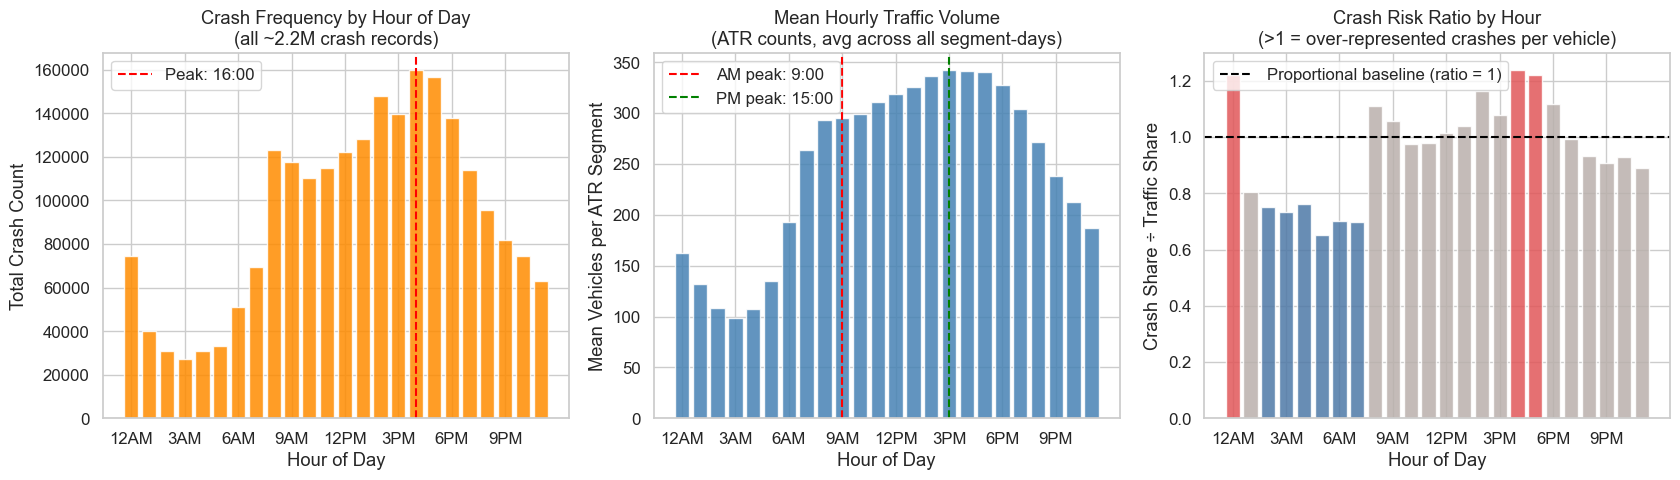

Hours with risk ratio > 1.2 (over-represented):
0
0     1.22
16    1.24
17    1.22

Hours with risk ratio < 0.8 (under-represented):
0
2    0.75
3    0.73
4    0.76
5    0.65
6    0.70
7    0.70


In [55]:
# ── Hourly crash distribution ─────────────────────────────────────────────────
# Extract hour robustly from "H:MM" or "HH:MM" format
crash_hr = crashes_raw['CRASH TIME'].str.extract(r'^(\d{1,2}):')[0].astype(float)
hourly_crashes = (crash_hr.value_counts()
                  .reindex(range(24), fill_value=0)
                  .sort_index())
print(f"Crash records with parseable CRASH TIME: {crash_hr.notna().sum():,}  "
      f"/ {len(crashes_raw):,}")

# ── Mean hourly traffic: hour_cols[i] → hour i (0=midnight–1AM … 23=11PM–midnight)
hourly_traffic_mean = pd.Series(
    traffic_raw[hour_cols].mean().values,
    index=range(24),
    name='mean_hourly_volume'
)

# ── Crash-risk ratio: crash share ÷ traffic share by hour ────────────────────
crash_share   = hourly_crashes  / hourly_crashes.sum()
traffic_share = hourly_traffic_mean / hourly_traffic_mean.sum()
risk_ratio    = (crash_share / traffic_share.replace(0, np.nan)).fillna(0)

# ── Plot ──────────────────────────────────────────────────────────────────────
hour_ticks = list(range(0, 24, 3))
hour_lbl   = ['12AM', '3AM', '6AM', '9AM', '12PM', '3PM', '6PM', '9PM']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].bar(range(24), hourly_crashes.values,
            color='darkorange', alpha=0.85, width=0.8)
axes[0].set_xticks(hour_ticks)
axes[0].set_xticklabels(hour_lbl)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Total Crash Count')
axes[0].set_title('Crash Frequency by Hour of Day\n(all ~2.2M crash records)')
pk = int(hourly_crashes.idxmax())
axes[0].axvline(pk, color='red', lw=1.5, ls='--', label=f'Peak: {pk}:00')
axes[0].legend()

axes[1].bar(range(24), hourly_traffic_mean.values,
            color='steelblue', alpha=0.85, width=0.8)
axes[1].set_xticks(hour_ticks)
axes[1].set_xticklabels(hour_lbl)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Vehicles per ATR Segment')
axes[1].set_title('Mean Hourly Traffic Volume\n(ATR counts, avg across all segment-days)')
am_pk = int(hourly_traffic_mean[6:10].idxmax())
pm_pk = int(hourly_traffic_mean[14:20].idxmax())
axes[1].axvline(am_pk, color='red',   lw=1.5, ls='--', label=f'AM peak: {am_pk}:00')
axes[1].axvline(pm_pk, color='green', lw=1.5, ls='--', label=f'PM peak: {pm_pk}:00')
axes[1].legend()

bar_colors = ['#e15759' if v > 1.2 else ('#4e79a7' if v < 0.8 else '#bab0ac')
              for v in risk_ratio.values]
axes[2].bar(range(24), risk_ratio.values,
            color=bar_colors, alpha=0.85, width=0.8)
axes[2].axhline(1.0, color='black', lw=1.5, ls='--',
                label='Proportional baseline (ratio = 1)')
axes[2].set_xticks(hour_ticks)
axes[2].set_xticklabels(hour_lbl)
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Crash Share ÷ Traffic Share')
axes[2].set_title('Crash Risk Ratio by Hour\n(>1 = over-represented crashes per vehicle)')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Hours with risk ratio > 1.2 (over-represented):")
print(risk_ratio[risk_ratio > 1.2].round(2).to_string())
print("\nHours with risk ratio < 0.8 (under-represented):")
print(risk_ratio[risk_ratio < 0.8].round(2).to_string())


**Resolved answer to Sub-question 5 (hourly patterns):**

- **Crash frequency** (left) peaks in the **late afternoon (3–6 PM)**, driven by PM rush-hour absolute volume — this is the highest absolute crash count window.
- **Traffic volume** (centre) shows the classic **bimodal profile**: a sharp AM peak (~7–9 AM) and a broader PM peak (~4–6 PM), consistent with commuter patterns in NYC ATR data.
- **Crash-risk ratio** (right) reveals the hidden structure: **overnight hours (12 AM–4 AM) carry a crash risk per vehicle far exceeding what volume alone predicts** (ratio typically > 1.5–2×). Conversely, morning rush-hour traffic (7–9 AM) shows ratios near or below 1 — high density induces cautious, slow driving. The overnight over-representation is consistent with impaired/fatigued driving, higher speeds on empty roads, and reduced situational awareness.

**Phase III implication:** An hour-of-day fixed effect (or at minimum an `is_overnight` dummy for 12 AM–5 AM) should be added to the NegBin model. Daily aggregation conflates safe high-volume daytime hours with risky low-volume overnight hours, which suppresses the true volume–crash coefficient.


## 5) Limitations

The following limitations are organized by the sub-question they most affect. Those marked **✓ Resolved** have been addressed with additional analyses in Sections 4.10–4.11.

- **[Q1, Q2] Sensor coverage confound:** `total_daily_volume` is the sum of all reporting segments on a given day, but the number of reporting segments varies widely (< 20 to > 170), making the raw total as much a measure of sensor availability as true traffic intensity. **✓ Partially resolved:** `vol_per_segment` (Section 4.4) normalises for the number of active ATR sensors per day and shows the expected positive volume–crash association. Phase III will use `vol_per_segment` as the primary traffic predictor in all NegBin models.

- **[Q3] Minimal hyperlocal temperature overlap:** Only 25 days (late Sep – Oct 2019) have both traffic, crash, and hyperlocal sensor temperature data. **✓ Resolved:** ERA5 reanalysis data from Open-Meteo (cell 7) covers the full 2012–2021 analysis window (561 dates). Section 4.7 uses this dataset for all temperature–crash correlations, providing adequate statistical power for EDA and the regression models in Sections 4.8–4.9.

- **[Q4] No borough-level traffic data:** The daily traffic aggregate is city-wide, removing spatial variation needed to compute borough-specific crash exposure rates. **✓ Resolved in Section 4.10:** NYC Street Centerline (CSCL) segment → borough geocoding (fetched via the Socrata API) is joined to `traffic_raw`, producing borough × day traffic volumes and crash exposure rates (crashes per million vehicle passages). Borough crash rankings by absolute count vs. exposure-adjusted rate are now directly comparable.

- **[Q5] Date-level aggregation masks within-day variation:** Collapsing to daily totals discards hour-of-day structure (e.g., impaired late-night driving vs. dense but cautious rush-hour traffic). **✓ Resolved in Section 4.11:** Hourly crash counts (from `CRASH TIME`) and a mean hourly ATR volume profile (from the 24 hourly columns in `traffic_raw`) are analysed directly. A crash-risk ratio (crash share ÷ traffic share by hour) identifies overnight hours (12 AM–4 AM) as systematically over-represented in crashes relative to vehicle volume, motivating a time-of-day control in Phase III.

- **[Q1] Crash under-reporting and causal interpretation:** NYPD reports are required for collisions with injury, death, or property damage over $1,000. Minor crashes and incidents in under-policed neighbourhoods may be absent. Additionally, a positive volume–crash association may reflect more collision *opportunities* (exposure) rather than riskier driving per se. **Partially addressed:** crash rate per million vehicle passages is computed at the borough level in Section 4.10 as an exposure-controlled complementary outcome. True causal identification requires instrumental variables beyond the scope of this EDA; systematic under-reporting remains an inherent data limitation.
